# EE 344 Assignment 1

Henry Adams

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt

- Load the CSV into a pandas DataFrame.
- Display column names, shape, and summary statistics (describe()).
- Identify missing values (if any) and clearly state how you handle them.

# Part 1 (Predicting Horse Power from Fuel Economy)

In [2]:
DATA_PATH = "data/FuelEconomy.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())
display(df.describe())
display(df.isna().sum()) # no missing values

Shape: (100, 2)

Columns:
['Horse Power', 'Fuel Economy (MPG)']


,Horse Power,Fuel Economy (MPG)
0,118.770799,29.344195
1,176.326567,24.695934
2,219.262465,23.952010
3,187.310009,23.384546
4,218.594340,23.426739


,Horse Power,Fuel Economy (MPG)
count,100.000000,100.000000
mean,213.676190,23.178501
std,62.061726,4.701666
min,50.000000,10.000000
25%,174.996514,20.439516
50%,218.928402,23.143192
75%,251.706476,26.089933
max,350.000000,35.000000


Horse Power           0
Fuel Economy (MPG)    0
dtype: int64

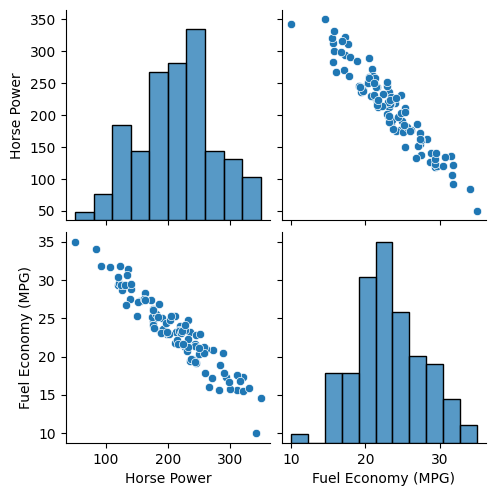

In [3]:
sns.pairplot(df) # just for fun

Helper functions below

In [4]:
def split_data(X, y, test_size=0.30, random_state=42):
    """70/30 random train-test split."""
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

def prepare_xy(df_in, target_col=None):
    """Drop missing rows, split into X and y."""
    df_clean = df_in.dropna().copy()
    X = df_clean.drop(columns=[target_col])
    y = df_clean[target_col]
    return X, y

def compute_metrics(y_true, y_pred):
    """Return MSE, MAE, R^2."""
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R^2": r2_score(y_true, y_pred),
    }
    
def _get_linear_parts(model, input_feature_names):
    """Extract (intercept, coefficients, feature_names) from either:
       - LinearRegression
       - Pipeline(PolynomialFeatures -> LinearRegression)
    """
    # Plain LinearRegression
    if isinstance(model, LinearRegression):
        intercept = float(model.intercept_)
        coefs = np.array(model.coef_).ravel()
        feat_names = np.array(list(input_feature_names))
        return intercept, coefs, feat_names

    # Polynomial pipeline
    if hasattr(model, "named_steps") and "poly" in model.named_steps and "lr" in model.named_steps:
        poly = model.named_steps["poly"]
        lr = model.named_steps["lr"]

        feat_names = poly.get_feature_names_out(input_features=list(input_feature_names))
        intercept = float(lr.intercept_)
        coefs = np.array(lr.coef_).ravel()
        return intercept, coefs, np.array(feat_names)

    raise ValueError("Unsupported model type for equation printing.")
    
def print_fitted_equation(model, input_feature_names, target_name=None, top_k_terms=15):
    """Print a readable fitted equation.

    For polynomial models, the number of terms can become very large,
    so we print only the TOP-K terms by absolute coefficient magnitude.
    """
    intercept, coefs, feat_names = _get_linear_parts(model, input_feature_names)

    # Sort by absolute coefficient magnitude
    order = np.argsort(np.abs(coefs))[::-1]
    order = order[:min(top_k_terms, len(coefs))]

    terms = []
    for idx in order:
        terms.append(f"({coefs[idx]:+.4f}) * {feat_names[idx]}")

    eq = f"{target_name} = {intercept:.4f} " + " ".join(terms)

    print("\n--- Fitted Model Equation (Top Terms) ---")
    print(eq)
    if len(coefs) > top_k_terms:
        print(f"(Showing top {top_k_terms} terms out of {len(coefs)} total terms.)")

def run_models_and_evaluate(df_in, degrees=(1, 2, 3, 4),
                            target_col=None, test_size=0.30, random_state=42,
                            show_equation=True, show_plots=True, top_k_terms=15):
    """Train/evaluate linear (deg=1) + polynomial regression models.

    Returns a DataFrame of metrics.
    Also prints fitted equations and scatter plots (test set) for each model.
    """
    X, y = prepare_xy(df_in, target_col=target_col)
    X_train, X_test, y_train, y_test = split_data(X, y, test_size=test_size, random_state=random_state)

    rows = []

    for deg in degrees:
        if deg == 1:
            model = LinearRegression()
            model_name = "Linear Regression"
        else:
            model = Pipeline([
                ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
                ("lr", LinearRegression())
            ])
            model_name = f"Polynomial Regression (degree={deg})"

        # Fit model
        model.fit(X_train, y_train)

        # Predict
        yhat_train = model.predict(X_train)
        yhat_test  = model.predict(X_test)

        # Metrics
        train_m = compute_metrics(y_train, yhat_train)
        test_m  = compute_metrics(y_test, yhat_test)

        # Report equation + plot (TEST set)
        print("\n============================================================")
        print(f"Model: {model_name}")
        print("============================================================")

        if show_equation:
            print_fitted_equation(
                model=model,
                input_feature_names=X_train.columns,
                target_name=target_col,
                top_k_terms=top_k_terms
            )

        # if show_plots:
        #     plot_actual_vs_predicted_test(
        #         y_test=y_test,
        #         y_pred=yhat_test,
        #         title=f"{scenario_name} — {model_name} (Test Set: Actual vs Predicted)"
        #     )

        rows.append({
            "Model": model_name,
            "Train MSE": train_m["MSE"],
            "Train MAE": train_m["MAE"],
            "Train R^2": train_m["R^2"],
            "Test MSE": test_m["MSE"],
            "Test MAE": test_m["MAE"],
            "Test R^2": test_m["R^2"],
            "Train size": len(X_train),
            "Test size": len(X_test),
        })

    return pd.DataFrame(rows)

Training models to predict HP

In [5]:
results_A = run_models_and_evaluate(
    df_in=df,
    target_col="Horse Power",
    degrees=(1, 2, 3, 4),
    show_equation=True,
    show_plots=True,
    top_k_terms=15
)

display(results_A)


Model: Linear Regression

--- Fitted Model Equation (Top Terms) ---
Horse Power = 500.3638 (-12.3785) * Fuel Economy (MPG)

Model: Polynomial Regression (degree=2)

--- Fitted Model Equation (Top Terms) ---
Horse Power = 457.3741 (-8.5915) * Fuel Economy (MPG) (-0.0800) * Fuel Economy (MPG)^2

Model: Polynomial Regression (degree=3)

--- Fitted Model Equation (Top Terms) ---
Horse Power = 355.6514 (+6.0952) * Fuel Economy (MPG) (-0.7505) * Fuel Economy (MPG)^2 (+0.0097) * Fuel Economy (MPG)^3

Model: Polynomial Regression (degree=4)

--- Fitted Model Equation (Top Terms) ---
Horse Power = 90.1049 (+61.1736) * Fuel Economy (MPG) (-4.7743) * Fuel Economy (MPG)^2 (+0.1339) * Fuel Economy (MPG)^3 (-0.0014) * Fuel Economy (MPG)^4


,Model,Train MSE,Train MAE,Train R^2,Test MSE,Test MAE,Test R^2,Train size,Test size
0,Linear Regression,357.699180,16.061689,0.906320,318.561087,14.940628,0.912561,70,30
1,Polynomial Regression (degree=2),350.879731,15.995824,0.908106,331.105434,15.148330,0.909118,70,30
2,Polynomial Regression (degree=3),345.108668,15.746762,0.909618,318.404012,14.764973,0.912604,70,30
3,Polynomial Regression (degree=4),339.700171,15.508465,0.911034,313.798757,14.735471,0.913868,70,30


# Model Evaluation + Discussion

As expected, all models perform quite well (from plotting, we see that relationship between Fuel Economy and HP _looks_ mostly linear). Train and test metrics are presented in the table above. It is worth noting that, since the relationship between the two variables is mostly linear, the coefficients/weights for the higher order terms in the polynomial regression are quite small (for example, the weight given to the 4th order term in the last polynomial regression is only -0.0014, compared with 90.1049 for the zeroth order term in the same regression).

- Which model performs best on the test set and why? Does increasing polynomial degree always improve performance?

The 4th order model _technically_ performs the best on the test set (MSE of 313.7, compared with 318.5 for the linear model), although the performance of each model on the test is almost identical. So, increasing polynomial degree marginally improves performance on the testing set - but this is expected, since we _know_ that the relationship between _X_ and _y_ is more or less linear just from plotting (i.e. if we work with a higher order polynomial regression, we should expect the weights of the higher order terms to be small. The remaining error in each of the regressions is just due to the inherent noise in the dataset).

# Part 2 (Predicting Electricity Consumption)

In [6]:
DATA_PATH = "data/electricity_consumption_based_weather_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head(n=5))
display(df.describe())
display(df.isna().sum())

Shape: (1433, 6)

Columns:
['date', 'AWND', 'PRCP', 'TMAX', 'TMIN', 'daily_consumption']


,date,AWND,PRCP,TMAX,TMIN,daily_consumption
0,2006-12-16,2.5,0.0,10.6,5.0,1209.176
1,2006-12-17,2.6,0.0,13.3,5.6,3390.460
2,2006-12-18,2.4,0.0,15.0,6.7,2203.826
3,2006-12-19,2.4,0.0,7.2,2.2,1666.194
4,2006-12-20,2.4,0.0,7.2,1.1,2225.748


,AWND,PRCP,TMAX,TMIN,daily_consumption
count,1418.000000,1433.000000,1433.000000,1433.000000,1433.000000
mean,2.642313,3.800488,17.187509,9.141242,1561.078061
std,1.140021,10.973436,10.136415,9.028417,606.819667
min,0.000000,0.000000,-8.900000,-14.400000,14.218000
25%,1.800000,0.000000,8.900000,2.200000,1165.700000
50%,2.400000,0.000000,17.800000,9.400000,1542.650000
75%,3.300000,1.300000,26.100000,17.200000,1893.608000
max,10.200000,192.300000,39.400000,27.200000,4773.386000


date                  0
AWND                 15
PRCP                  0
TMAX                  0
TMIN                  0
daily_consumption     0
dtype: int64

We find that Average Wind Speed has 15 missing values, so we fill them in with zeros. Another option would be to fill with the mean value.

In [7]:
# fill in missing values of AWND with zeros, and drop the date column
df_filled = df.copy()

df_filled["AWND"] = df_filled["AWND"].fillna(0)
# df_filled["AWND"] = df_filled["AWND"].fillna(df_filled["AWND"].mean()) # another option

df_filled = df_filled.drop(columns=["date"])

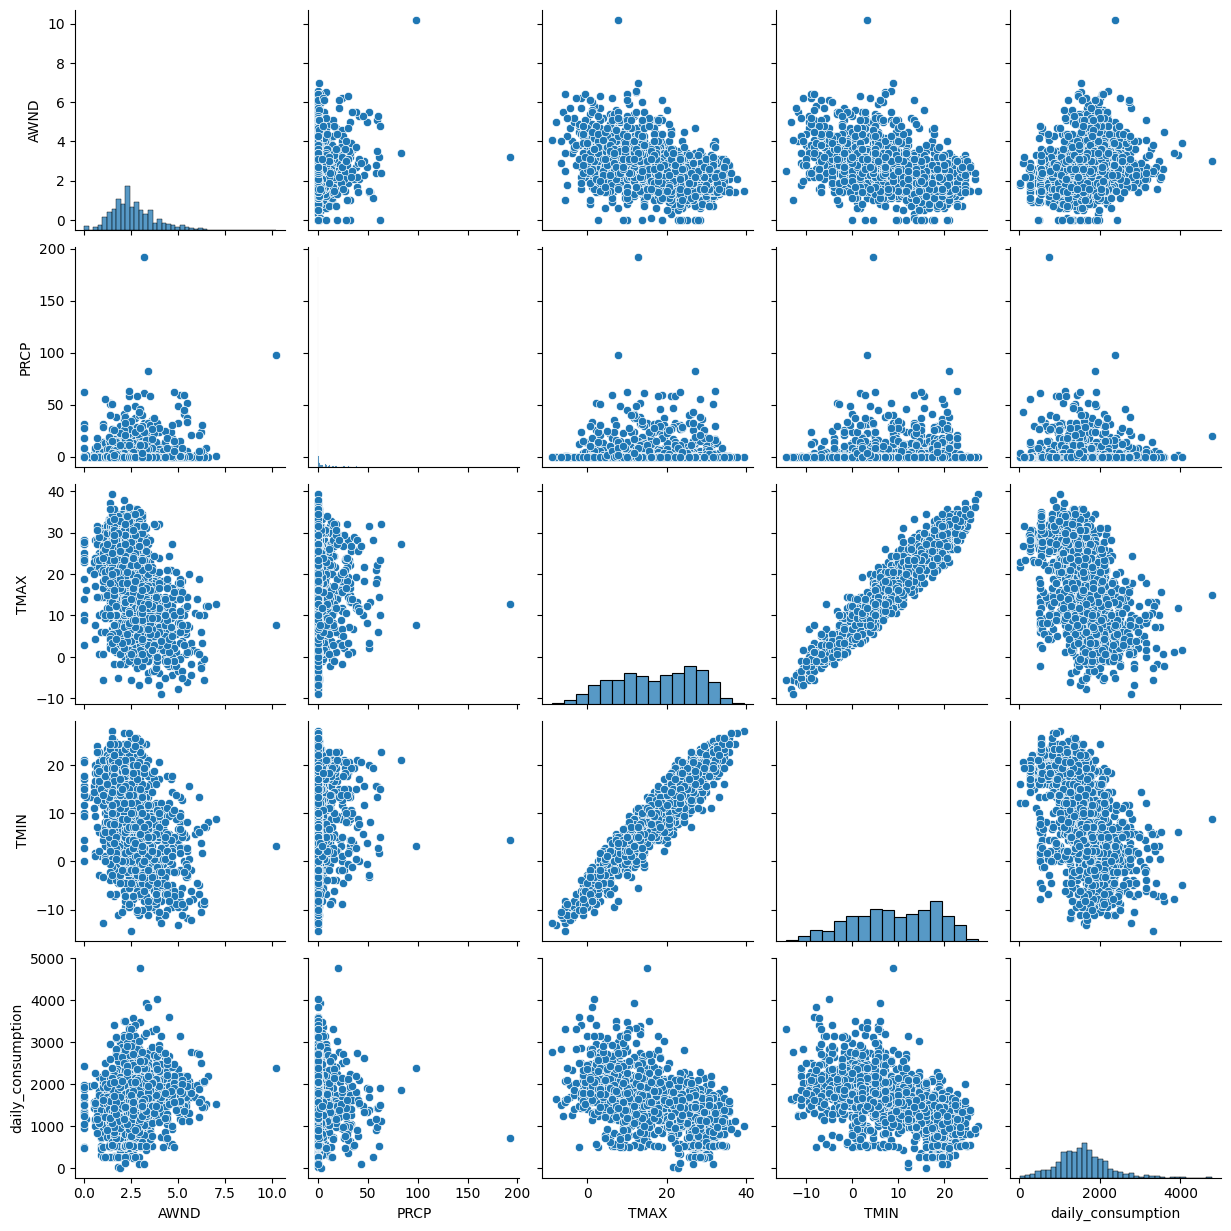

In [8]:
sns.pairplot(df_filled) # just for fun

In [9]:
results_B = run_models_and_evaluate(
    df_in=df_filled,
    target_col="daily_consumption",
    degrees=(1, 2, 3, 4),
    show_equation=True,
    show_plots=True,
    top_k_terms=15
)

display(results_B)


Model: Linear Regression

--- Fitted Model Equation (Top Terms) ---
daily_consumption = 2008.3884 (-20.4600) * TMIN (-14.0600) * TMAX (-4.0202) * AWND (-2.5864) * PRCP

Model: Polynomial Regression (degree=2)

--- Fitted Model Equation (Top Terms) ---
daily_consumption = 2280.4193 (-65.4789) * TMAX (+22.9325) * TMIN (-10.8071) * PRCP (-9.5029) * AWND^2 (+7.0392) * AWND (+2.8768) * AWND TMAX (-2.1648) * TMAX TMIN (+1.8729) * AWND PRCP (+1.6858) * TMAX^2 (-1.5644) * PRCP TMIN (+1.3101) * PRCP TMAX (-0.9417) * AWND TMIN (+0.1321) * TMIN^2 (-0.0524) * PRCP^2

Model: Polynomial Regression (degree=3)

--- Fitted Model Equation (Top Terms) ---
daily_consumption = 1646.6857 (+320.6569) * AWND (-90.9419) * AWND^2 (+39.3207) * TMAX (-20.2004) * TMIN (+15.6365) * PRCP (-15.2579) * AWND TMIN (+11.1848) * TMAX TMIN (-8.4062) * TMAX^2 (-5.1792) * TMIN^2 (-5.0413) * AWND PRCP (+4.8469) * AWND TMAX TMIN (+4.5420) * AWND^2 TMAX (+3.6991) * AWND^3 (-3.2083) * AWND^2 TMIN (-2.6714) * AWND TMIN^2
(Showin

,Model,Train MSE,Train MAE,Train R^2,Test MSE,Test MAE,Test R^2,Train size,Test size
0,Linear Regression,274810.152693,386.852433,0.272988,237065.623968,365.391808,0.311935,1003,430
1,Polynomial Regression (degree=2),269028.833893,382.602116,0.288282,233488.955382,361.183679,0.322316,1003,430
2,Polynomial Regression (degree=3),262444.409795,378.111368,0.305701,234993.695292,366.975326,0.317948,1003,430
3,Polynomial Regression (degree=4),255594.534986,373.942507,0.323823,322568.995581,397.167061,0.063768,1003,430


# Model Evaluation + Discussion

Results are presented in the table above.

- Which model generalizes best (best test performance), and what does that tell you about the
relationship between weather and electricity usage?

The degree 2 polynomial regression performs marginally better (Test R^2 of 0.322, compared with the next highest Test R^2 of 0.317 from the degree 3 model, and 0.311 from the linear model) than the other models, although performance is approximately equivalent between the degree 1, 2, and 3 models. This tells us that the relationship between the weather indicators in the dataset and electricity usage is **not** linear, since our linear and polynomial models are poor predictors of electricity usage.

- Do polynomial models improve the fit compared to linear regression? If yes, why might electricity
consumption have nonlinear dependence on weather?

No - the Test MAE is approximately the same for all models (between 360 and 370 for the degree 1, 2, and 3 models).

- If higher-degree models perform worse on the test set, explain this behavior using evidence from
metrics (e.g., train error decreases but test error increases).

A notable exception to the "all the models have approximately equal performance" trend is the degree 4 polynomial regression, which technically has the highest training R^2, but has an abysmal Test R^2 of 0.06, meaning that the model is only slightly better than just predicting the mean weather usage. If we preprocess differently by replacing N/A values for wind speed with the mean AWND rather than zero, the R^2 for the degree 4 model is actually *negative*, meaning it is worse than just predicting the mean value. This is almost certainly because the 4-th order term explodes when a certain variable gets large, leading to bigger errors for datapoints in the tails of the distribution.

- If none of the models achieve good test performance, provide at least two reasons supported by
your outputs (e.g., limited feature set, high noise, unmodeled drivers such as occupancy/behavior,
seasonal effects).

Reason 1: There are temporal factors that affect electricity usage (people use more electricity during the day, and less at night, for example), and these aren't captured in our model.

Reason 2: As seen in the scatterplots above, a lot of the relationships in the data just aren't linear, so our linear/polynomial models are really limited.

Reason 3: Low signal to noise ratio. Predicting electricity usage might just be a hard problem, and there are lots of outliers (i.e. maybe one house in the dataset is a Bitcoin farm).